In [51]:
#created on 17/04/2026 by James McLoughlin

In [81]:
from pathlib import Path
import os
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show
import rasterio.merge
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.io import MemoryFile
from rasterio.merge import merge
from rasterio.features import shapes
import numpy as np
from scipy.ndimage import median_filter
from shapely.geometry import shape

In [82]:
base = Path("C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/two_years")

NDI_out = base/"Processed_data"/"NDI"
NDI_out.mkdir(parents=True, exist_ok=True)
mosaic_out = base/"Processed_data"/"Mosaic"
mosaic_out.mkdir(parents=True, exist_ok=True)
classified_out = base/"Processed_data"/"classified"
classified_out.mkdir(parents=True, exist_ok=True)
polygon_out = base/"Processed_data"/"polygon"
polygon_out.mkdir(parents=True, exist_ok=True)

NDI_choice = {
    "NDVI": 0,
    "NDWI": 1,
    "NDSI": 0,
}

In [83]:
# Dictionaries describing the bands of the landsat satellites and  
satbands = {
    "LT05": {
        "B1":"BLUE", 
        "B2":"GREEN",
        "B3":"RED",
        "B4":"NIR",
        "B5":"SWIR1",
        "B6":"TIR",
        "B7":"SWIR2"
    },
    "LT07":{
        "B1":"BLUE", 
        "B2":"GREEN",
        "B3":"RED",
        "B4":"NIR",
        "B5":"SWIR1",
        "B6":"TIR",
        "B7":"SWIR2",
        "B8":"PAN"
    },
    "LC08":{
        "B1":"COAST/AERO", 
        "B2":"BLUE",
        "B3":"GREEN",
        "B4":"RED",
        "B5":"NIR",
        "B6":"SWIR1",
        "B7":"SWIR2",
        "B8":"PAN",
        "B9":"CIRRUS",
        "B10":"TIR1",
        "B11":"TIR2",
    },
    "LC09":{
        "B1":"COAST/AERO", 
        "B2":"BLUE",
        "B3":"GREEN",
        "B4":"RED",
        "B5":"NIR",
        "B6":"SWIR1",
        "B7":"SWIR2",
        "B8":"PAN",
        "B9":"CIRRUS",
        "B10":"TIR1",
        "B11":"TIR2",
    },
}

index_to_bands = {
    "NDVI": ["RED", "NIR"],
    "NDWI": ["GREEN", "NIR"]
}

In [84]:
records = []
raw_data = base/"raw_data"
for folder in raw_data.iterdir():
    if folder.is_dir() and "Mosiac" not in folder.name:
        for file in folder.glob("*_SR_B*.TIF"):
            parts = file.name.split("_")
            sat = parts[0]
            band = parts[-1].replace(".TIF", "")
            records.append({
                "folder": folder.name,
                "file": file.name,
                "year": parts[3][:4],
                "satellite": sat,
                "path": file,
                "path_row": parts[2],
                "band": band,
                "colour": satbands[sat][band]
            })
df = pd.DataFrame(records)

In [85]:
bands = set()
for idx, use in NDI_choice.items():
    if use:
        bands.update(index_to_bands[idx])
band_order = ["COAST/AERO","BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2","PAN","CIRRUS","TIR1","TIR2"]
NDI = [b for b in band_order if b in bands]

In [90]:
for yr in df["year"].unique():
    for pathrow in df["path_row"].unique():
        green_path = df[(df["colour"] == NDI[0]) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
        nir_path = df[(df["colour"] == NDI[1]) & (df["year"] == yr) & (df["path_row"] == pathrow)]["path"].iloc[0]
    
        with rio.open(green_path) as g_src, rio.open(nir_path) as n_src: 
            green = g_src.read(1).astype("float32")
            nir   = n_src.read(1).astype("float32")
            ndwi = (green - nir) / (green + nir)
            # handle divide-by-zero
            ndwi[np.isnan(ndwi)] = -9999
            ndwi_out = NDI_out / f"{yr}_{pathrow}_NDWI.tif"
            meta = g_src.meta.copy()
            meta.update(dtype="float32", nodata=-9999)
            
        with rio.open(ndwi_out, "w", **meta) as dst:
            dst.write(ndwi, 1)

C:\Users\jj_mc\AppData\Local\Temp\ipykernel_16208\492877008.py:9: RuntimeWarning: invalid value encountered in divide
  ndwi = (green - nir) / (green + nir)
C:\Users\jj_mc\AppData\Local\Temp\ipykernel_16208\492877008.py:9: RuntimeWarning: invalid value encountered in divide
  ndwi = (green - nir) / (green + nir)
C:\Users\jj_mc\AppData\Local\Temp\ipykernel_16208\492877008.py:9: RuntimeWarning: invalid value encountered in divide
  ndwi = (green - nir) / (green + nir)
C:\Users\jj_mc\AppData\Local\Temp\ipykernel_16208\492877008.py:9: RuntimeWarning: invalid value encountered in divide
  ndwi = (green - nir) / (green + nir)
C:\Users\jj_mc\AppData\Local\Temp\ipykernel_16208\492877008.py:9: RuntimeWarning: invalid value encountered in divide
  ndwi = (green - nir) / (green + nir)
C:\Users\jj_mc\AppData\Local\Temp\ipykernel_16208\492877008.py:9: RuntimeWarning: invalid value encountered in divide
  ndwi = (green - nir) / (green + nir)
C:\Users\jj_mc\AppData\Local\Temp\ipykernel_16208\49287700

In [91]:
for yr in df["year"].unique():
    for pathrow in df["path_row"].unique():
        ndwi_img = NDI_out/f"{yr}_{pathrow}_NDWI.tif"
        with rio.open(ndwi_img) as src:
            ndwi = src.read(1)
            meta = src.meta.copy()
            water = np.where(ndwi>0,1,0).astype("uint8")
            clean = median_filter(water, size=3).astype("uint8")
            meta.update(dtype="uint8", nodata=0) 
            img_save = classified_path / f"{yr}_{pathrow}_classified_ndwi.tif"
        with rio.open(img_save, "w", **meta) as dst:
            dst.write(clean,1)    

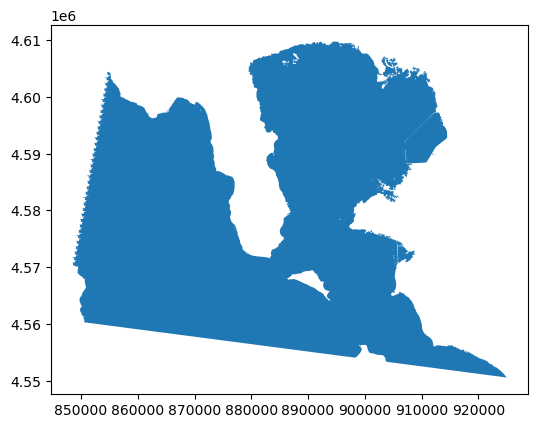

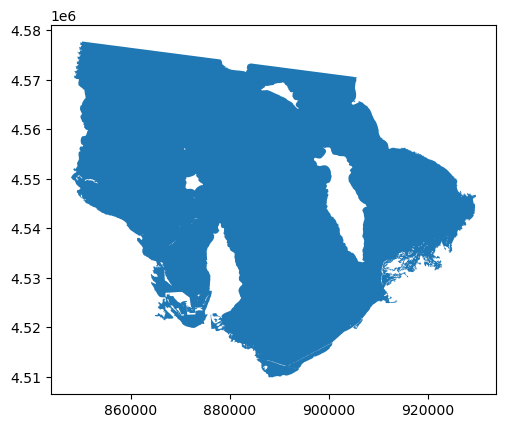

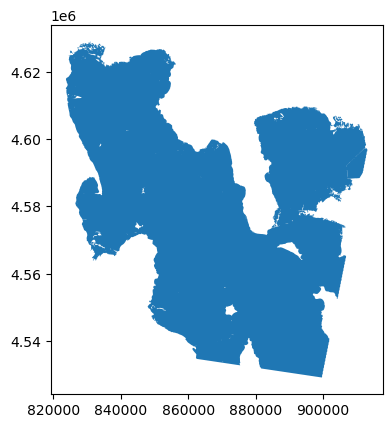

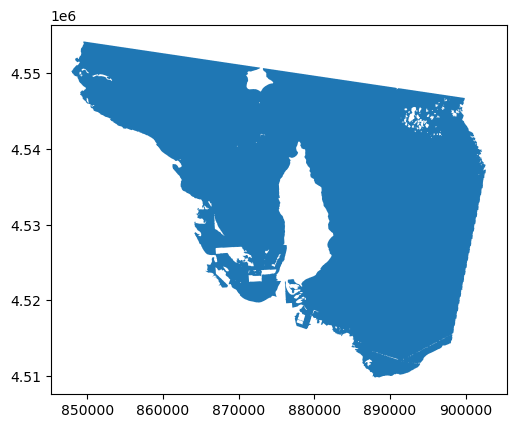

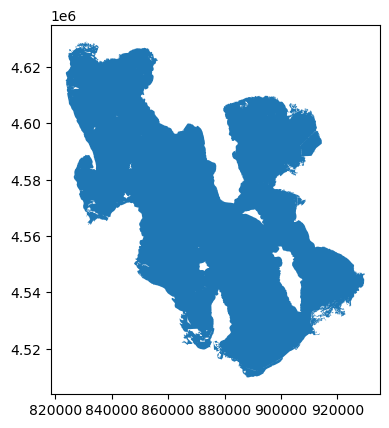

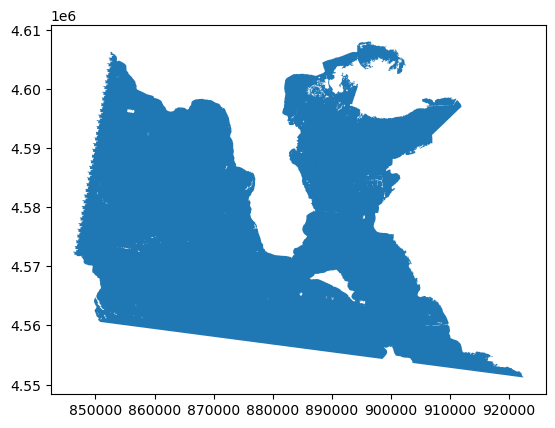

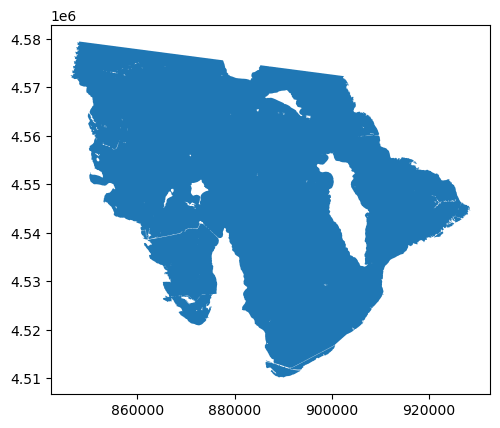

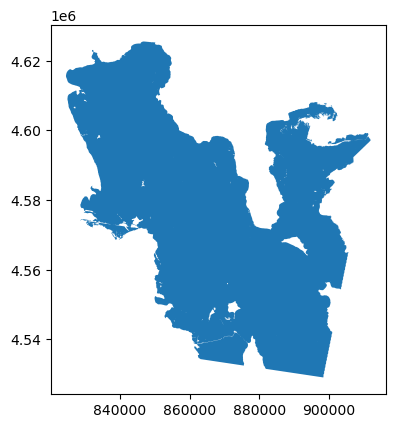

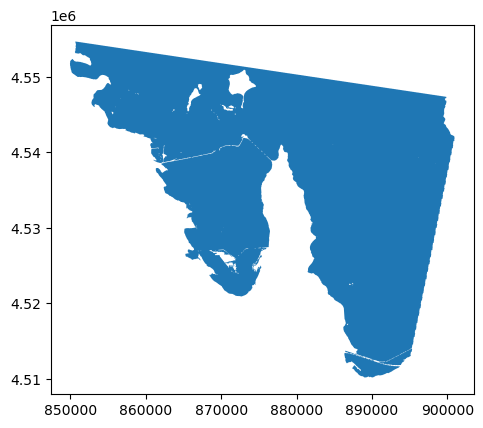

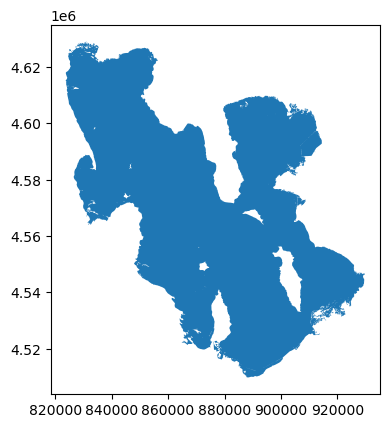

In [96]:
all_polygons = []
gdf_all = None
gdf = None
largest = None
for yr in df["year"].unique():
    for pathrow in df["path_row"].unique():
        ndwi_classified = classified_path / f"{yr}_{pathrow}_classified_ndwi.tif"
        with rio.open(ndwi_classified) as src:
            image = src.read(1)
            transform = src.transform
            results = shapes(image, transform=transform)
            
        water_geoms = []
        for geom, value in results:
            if value == 1:
                water_geoms.append(geom)
        
        polygons = [shape(g) for g in water_geoms]
        gdf = gpd.GeoDataFrame(geometry=polygons, crs=src.crs)

        gdf = gdf.to_crs(32611)
        gdf["area"] = gdf.geometry.area

        largest_geom = gdf.loc[gdf["area"].idxmax()].geometry

        largest = gpd.GeoDataFrame(
            geometry=[largest_geom],
            crs=gdf.crs
        )
        poly_save = polygon_out / f"water_boundary_{yr}_{pathrow}.png"
        largest.plot().figure.savefig(poly_save)
        largest["year"] = yr
        largest["pathrow"] = pathrow
        all_polygons.append(largest)

    gdf_all = gpd.GeoDataFrame(pd.concat(all_polygons, ignore_index=True), crs=32611)
    polys_out = polygon_out / f"water_boundaries_{yr}_{pathrow}.shp"
    gdf_all.to_file(polys_out)
    merged_polygon = gdf_all.geometry.union_all()
    joined = gpd.GeoDataFrame(geometry=[merged_polygon], crs=gdf_all.crs)
    joined_out = polygon_out / f"joined_{yr}.shp" 
    joined.to_file(joined_out)
    full_save = polygon_out / f"full_{yr}.png"
    gpd.GeoSeries([merged_polygon], crs=gdf_all.crs).plot().figure.savefig(full_save)






#merged = gpd.GeoDataFrame(geometry=[gpd.GeoSeries(pd.concat(all_polygons)).unary_union], crs=32611)

#        fig, ax = plt.subplots(figsize=(10,10))
#        gpd.GeoDataFrame(geometry=[largest.geometry], crs=gdf.crs).plot(ax=ax, color="blue", edgecolor="black")
#        plt.show()

In [67]:
#### this scell works
file_list = [f for f in NDI_out.iterdir() if f.is_file()]
with rio.open(file_list[0]) as ref:
    target_crs = ref.crs
srcs = []
for f in file_list:
    src = rio.open(f)
    if src.crs != target_crs:
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
        meta = src.meta.copy()
        meta.update({
            "crs": target_crs,
            "transform": transform,
            "width": width,
            "height": height
        })
    
        data = np.empty((src.count, height, width), dtype=src.dtypes[0])
    
        for i in range(1, src.count + 1):
            reproject(
                source=rio.band(src, i),
                destination=data[i-1],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=target_crs,
                resampling=Resampling.nearest
            )
        memfile = MemoryFile()
        dataset = memfile.open(**meta)
        dataset.write(data)
        srcs.append(dataset)
    else:
        srcs.append(src)
mosaic, transform = merge(srcs)

out_path = mosaic_out / "NDWI-TEST.tif"
meta = srcs[0].meta.copy()
meta.update({
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": transform
})

with rio.open(out_path, "w", **meta) as dst:
    dst.write(mosaic)

print(f"Saved: {out_path}")

Saved: C:\RS_GIS\EGM722\Assignment\Grand_Canyon\USGS_data\Unzipped\Processed_data\Mosaic\NDWI-TEST.tif


In [32]:
mosaic_out = base/"Processed_data"/"Mosiac"
mosaic_out.mkdir(parents=True, exist_ok=True)

 
for yr in df["year"].unique():
    for colr in NDI:
        file_list = df[
            (df["year"] == yr) &
            (df["colour"] == colr)
            ]["path"].tolist()
        with rio.open(file_list[0]) as ref:
            target_crs = ref.crs
        srcs = []
        for f in file_list:
            src = rio.open(f)
            if src.crs != target_crs:
                data, meta = reproject_raster(src, target_crs)
                memfile = MemoryFile()
                dataset = memfile.open(**meta)
                dataset.write(data)
                srcs.append(dataset)
            else:
                srcs.append(src)
        mosaic, transform = merge(srcs)
        
        out_path = mosaic_out / f"{yr}_{colr}_mosaic.tif"
        meta = srcs[0].meta.copy()
        meta.update({
            "height": mosaic.shape[1],
            "width": mosaic.shape[2],
            "transform": transform
        })
        
        with rio.open(out_path, "w", **meta) as dst:
            dst.write(mosaic)
        
        print(f"Saved: {out_path}")

NameError: name 'reproject_raster' is not defined

In [65]:
#####a clean NDWI → mosaic pipeline with ~20 lines total (no MemoryFile confusion, no CRS headaches) 
#----- mamny crs mistmatch issues with this one so had could end up being longer then before

mosaic_out = base/"Processed_data"/"Mosaic"
mosaic_out.mkdir(parents=True, exist_ok=True)

files = [f for f in NDI_out.iterdir() if f.is_file()]

with rio.open(files[0]) as ref:
    target_crs = ref.crs
srcs = []
for f in files:
    src = rio.open(f)

    # ✔ IF CRS MATCHES → keep as is
    if src.crs == target_crs:
        srcs.append(src)
        continue

    # ✔ OTHERWISE → REAL reprojection (this is what was missing)
    transform, width, height = calculate_default_transform(
        src.crs, target_crs, src.width, src.height, *src.bounds
    )

    meta = src.meta.copy()
    meta.update({
        "crs": target_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    data = np.empty((src.count, height, width), dtype=src.dtypes[0])

    for i in range(1, src.count + 1):
        reproject(
            source=rio.band(src, i),
            destination=data[i-1],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=target_crs,
            resampling=Resampling.nearest
        )

    mem = MemoryFile()
    reprojected = mem.open(**meta)
    reprojected.write(data)

    srcs.append(reprojected)

# ✔ NOW merge is safe (all CRS aligned)
mosaic, transform = merge(srcs)

meta = srcs[0].meta.copy()
meta.update({
    "crs": target_crs,
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": transform
})

out_path = mosaic_out / "NDWI_SimpleTest.tif"

with rio.open(out_path, "w", **meta) as dst:
    dst.write(mosaic)

print(f"Saved: {out_path}")

Saved: C:\RS_GIS\EGM722\Assignment\Grand_Canyon\USGS_data\Unzipped\Processed_data\Mosaic\NDWI_SimpleTest.tif


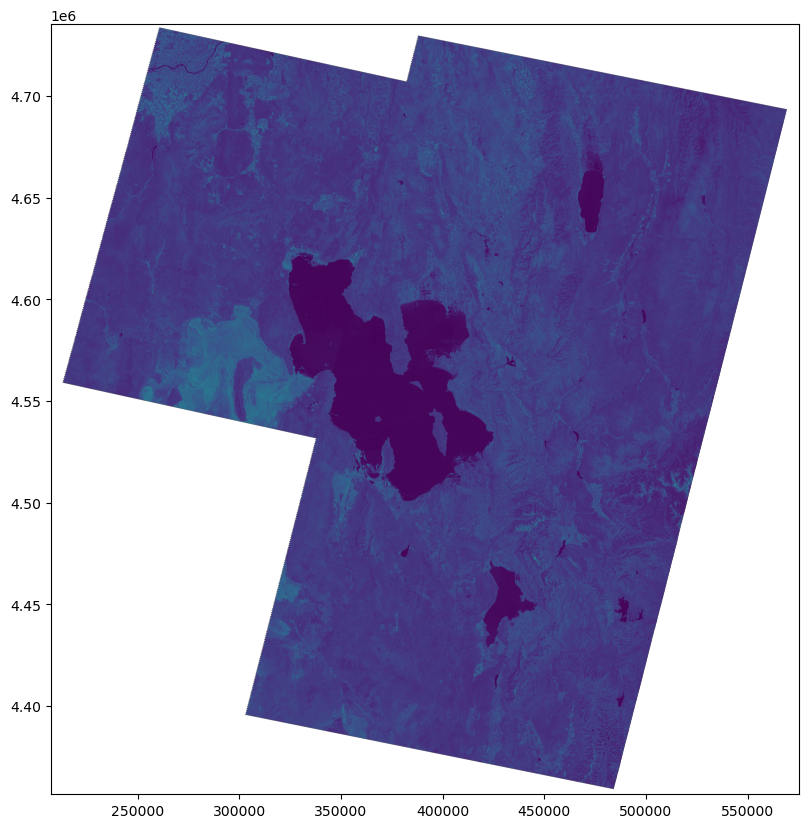

In [135]:
with rio.open("C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/single set/Mosiac/mosiac.tif") as dataset:
    fig, ax = plt.subplots(figsize=(10, 10))
    show(dataset, ax=ax)
plt.show()

In [14]:
def reproject_raster(src, dst_crs):
    transform, width, height = rio.warp.calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    data = np.empty((src.count, height, width), dtype=src.dtypes[0])

    for i in range(1, src.count + 1):
        reproject(
            source=rio.band(src, i),
            destination=data[i-1],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )

    return data, kwargs

In [58]:
def reproject_raster(src, dst_crs):
    transform, width, height = rio.warp.calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )

    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    data = np.empty((src.count, height, width), dtype=src.dtypes[0])

    for i in range(1, src.count + 1):
        reproject(
            source=rio.band(src, i),
            destination=data[i-1],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.nearest
        )

    return data, kwargs
    
mosaic_out = base/"Processed_data"/"Mosiac"
mosaic_out.mkdir(parents=True, exist_ok=True)

 
for yr in df["year"].unique():
    for colr in NDI:
        file_list = df[
            (df["year"] == yr) &
            (df["colour"] == colr)
            ]["path"].tolist()
        srcs = []
        for f in file_list:
            src = rio.open(f)
            if src.crs != target_crs:
                data, meta = reproject_raster(src, target_crs)
                srcs.append((data, meta))
            else:
                srcs.append((src.read(), src.meta))
        datasets = []
        for data, meta in srcs:
            memfile = MemoryFile()
            dataset = memfile.open(**meta)
            dataset.write(data)
            datasets.append(dataset)
        mosaic, transform = merge(datasets)
        print(mosaic.shape)
#            arrays.append(data)
#            srcs.append(src)
#            file_list = df[
#                (df["year"] == yr) &
#                (df["colour"] == colr)
#                ]["path"].tolist()
#            scrs = [rio.open(f) for f in file_list]
#            mosaic, transform = merge(srcs)
#            out_path = mosaic_out / f"{yr}_{colr}_mosaic.tif")
#            rio.merge.merge(file_list, dst_path = out_path)


(1, 11746, 19958)
(1, 11746, 19958)


In [55]:
def clipping(datafile):
    for file in parent.rglob(datafile):
        print(file)
        with rio.open(file) as data:
            geom = [feature["geometry"] for feature in boundary.__geo_interface__["features"]]
            out_image, out_transform = mask(data, geom, crop=True)
            fig, ax2 = plt.subplots(figsize=(10, 10))
            show(out_image, ax=ax2)